In [1]:
import numpy as np 
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [41]:
df = pd.read_csv('Breast_cancer_dataset.csv')
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [6]:
df.shape

(569, 33)

In [4]:
df.columns

Index(['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst', 'Unnamed: 32'],
      dtype='object')

In [5]:
df.isnull().sum()

id                           0
diagnosis                    0
radius_mean                  0
texture_mean                 0
perimeter_mean               0
area_mean                    0
smoothness_mean              0
compactness_mean             0
concavity_mean               0
concave points_mean          0
symmetry_mean                0
fractal_dimension_mean       0
radius_se                    0
texture_se                   0
perimeter_se                 0
area_se                      0
smoothness_se                0
compactness_se               0
concavity_se                 0
concave points_se            0
symmetry_se                  0
fractal_dimension_se         0
radius_worst                 0
texture_worst                0
perimeter_worst              0
area_worst                   0
smoothness_worst             0
compactness_worst            0
concavity_worst              0
concave points_worst         0
symmetry_worst               0
fractal_dimension_worst      0
Unnamed:

In [42]:
df.drop(columns=['Unnamed: 32'],inplace=True)

In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

Successfully generated boxplots and saved to 'all_numerical_boxplots.png'


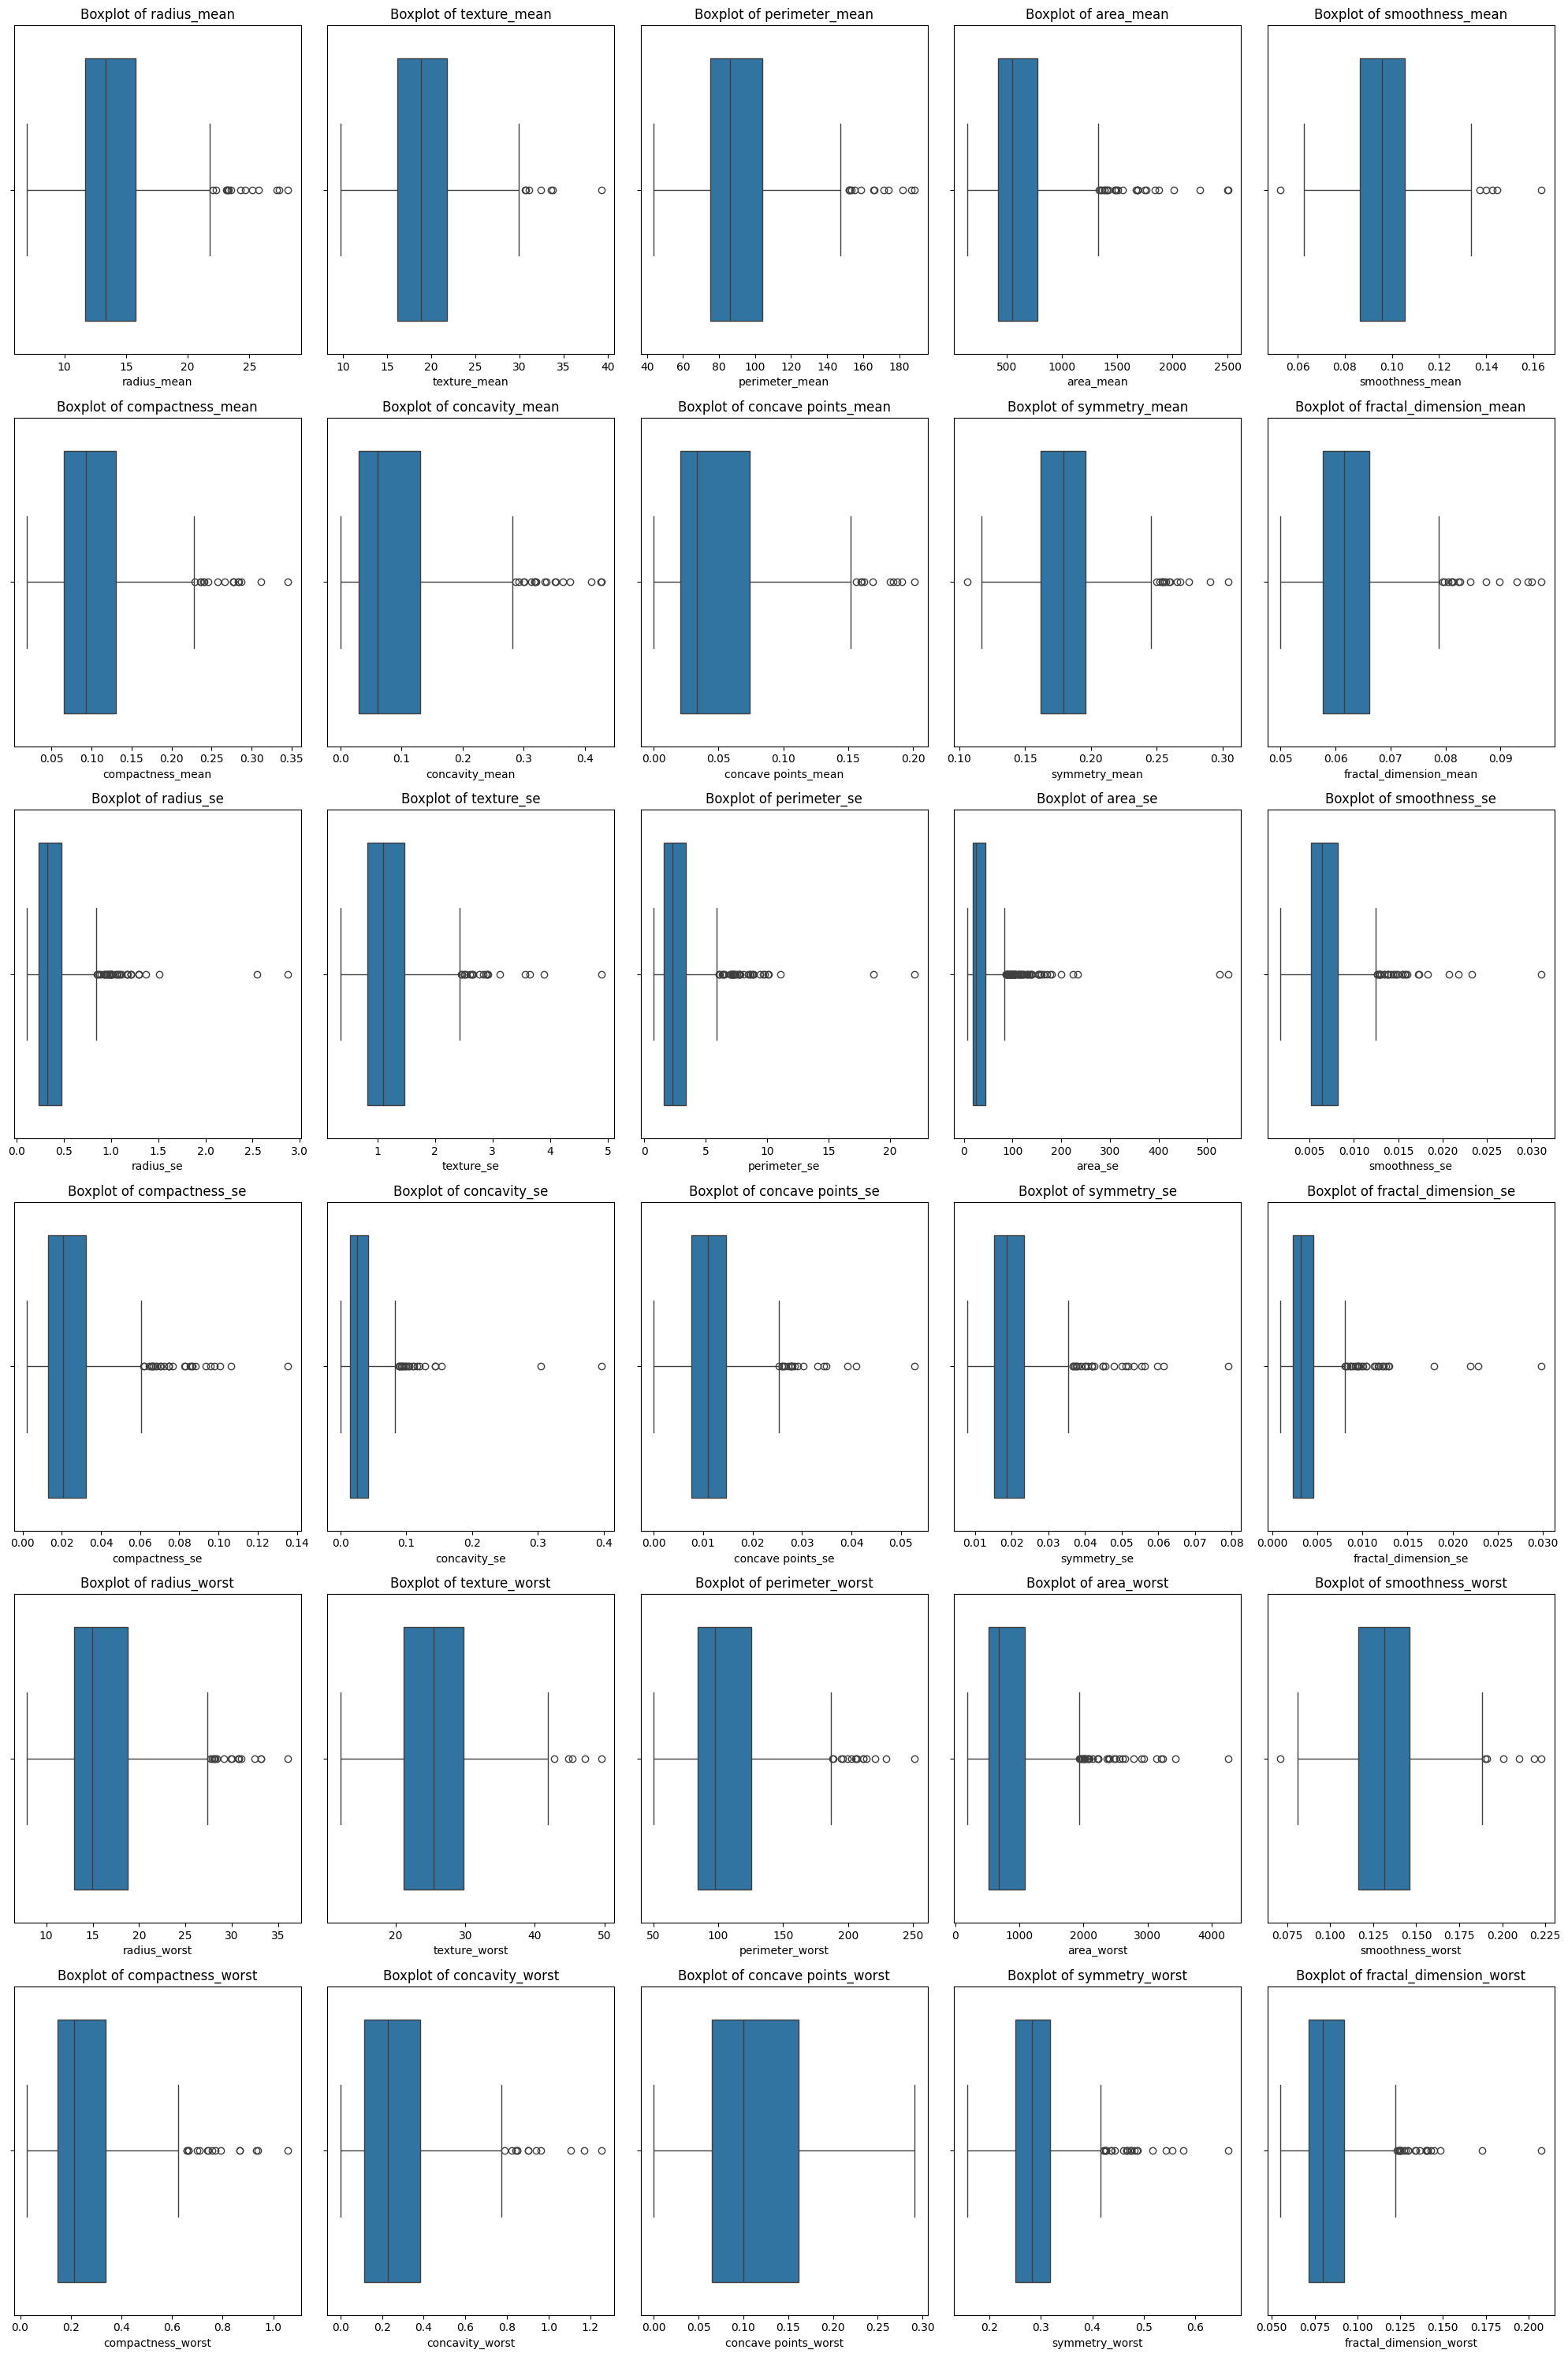

In [43]:


# Get all numerical columns from the DataFrame
all_numerical_cols = df.select_dtypes(include=np.number).columns

# Define columns you want to exclude
cols_to_exclude = ['id'] 
cols_to_exclude_lower = [col.lower() for col in cols_to_exclude]

# Create the final list of columns to plot
numerical_cols = [col for col in all_numerical_cols if col.lower() not in cols_to_exclude_lower]

n_cols_to_plot = len(numerical_cols)

if n_cols_to_plot == 0:
    print("No numerical columns found to plot (after exclusions).")
else:
    ncols = 5
    nrows = (n_cols_to_plot + ncols - 1) // ncols
    
    fig, axs = plt.subplots(nrows, ncols, figsize=(20, nrows * 5), squeeze=False)
    axs = axs.flatten()

    # --- UPDATED LOOP LOGIC ---
    plot_index = 0 # Use a separate index for placing plots on the axes
    for col in numerical_cols:
        
        # This check prevents the error:
        # Only plot if the column has at least one non-NaN value
        if df[col].notna().any():
            sns.boxplot(x=df[col], ax=axs[plot_index])
            axs[plot_index].set_title(f'Boxplot of {col}')
            plot_index += 1 # Only advance the plot index if we made a plot
        else:
            print(f"Skipping '{col}': Column contains only NaN values.")
    # --- END OF UPDATED LOGIC ---

    # Hide any unused subplots
    # Use 'plot_index' to know where the valid plots stopped
    for i in range(plot_index, len(axs)):
        axs[i].axis('off')

    plt.tight_layout()
    
    print(f"Successfully generated boxplots and saved to 'all_numerical_boxplots.png'")

In [45]:
all_numerical_cols = df.select_dtypes(include=np.number).columns
cols_to_exclude = ['id'] 
cols_to_exclude_lower = [col.lower() for col in cols_to_exclude]
numerical_cols = [col for col in all_numerical_cols if col.lower() not in cols_to_exclude_lower]
for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Condition banao
    condition = (df[col] >= lower_bound) & (df[col] <= upper_bound)

    df = df[condition]

print(f"Size after removing statistical outliers: {df.shape}")

Size after removing statistical outliers: (277, 32)


Successfully generated 


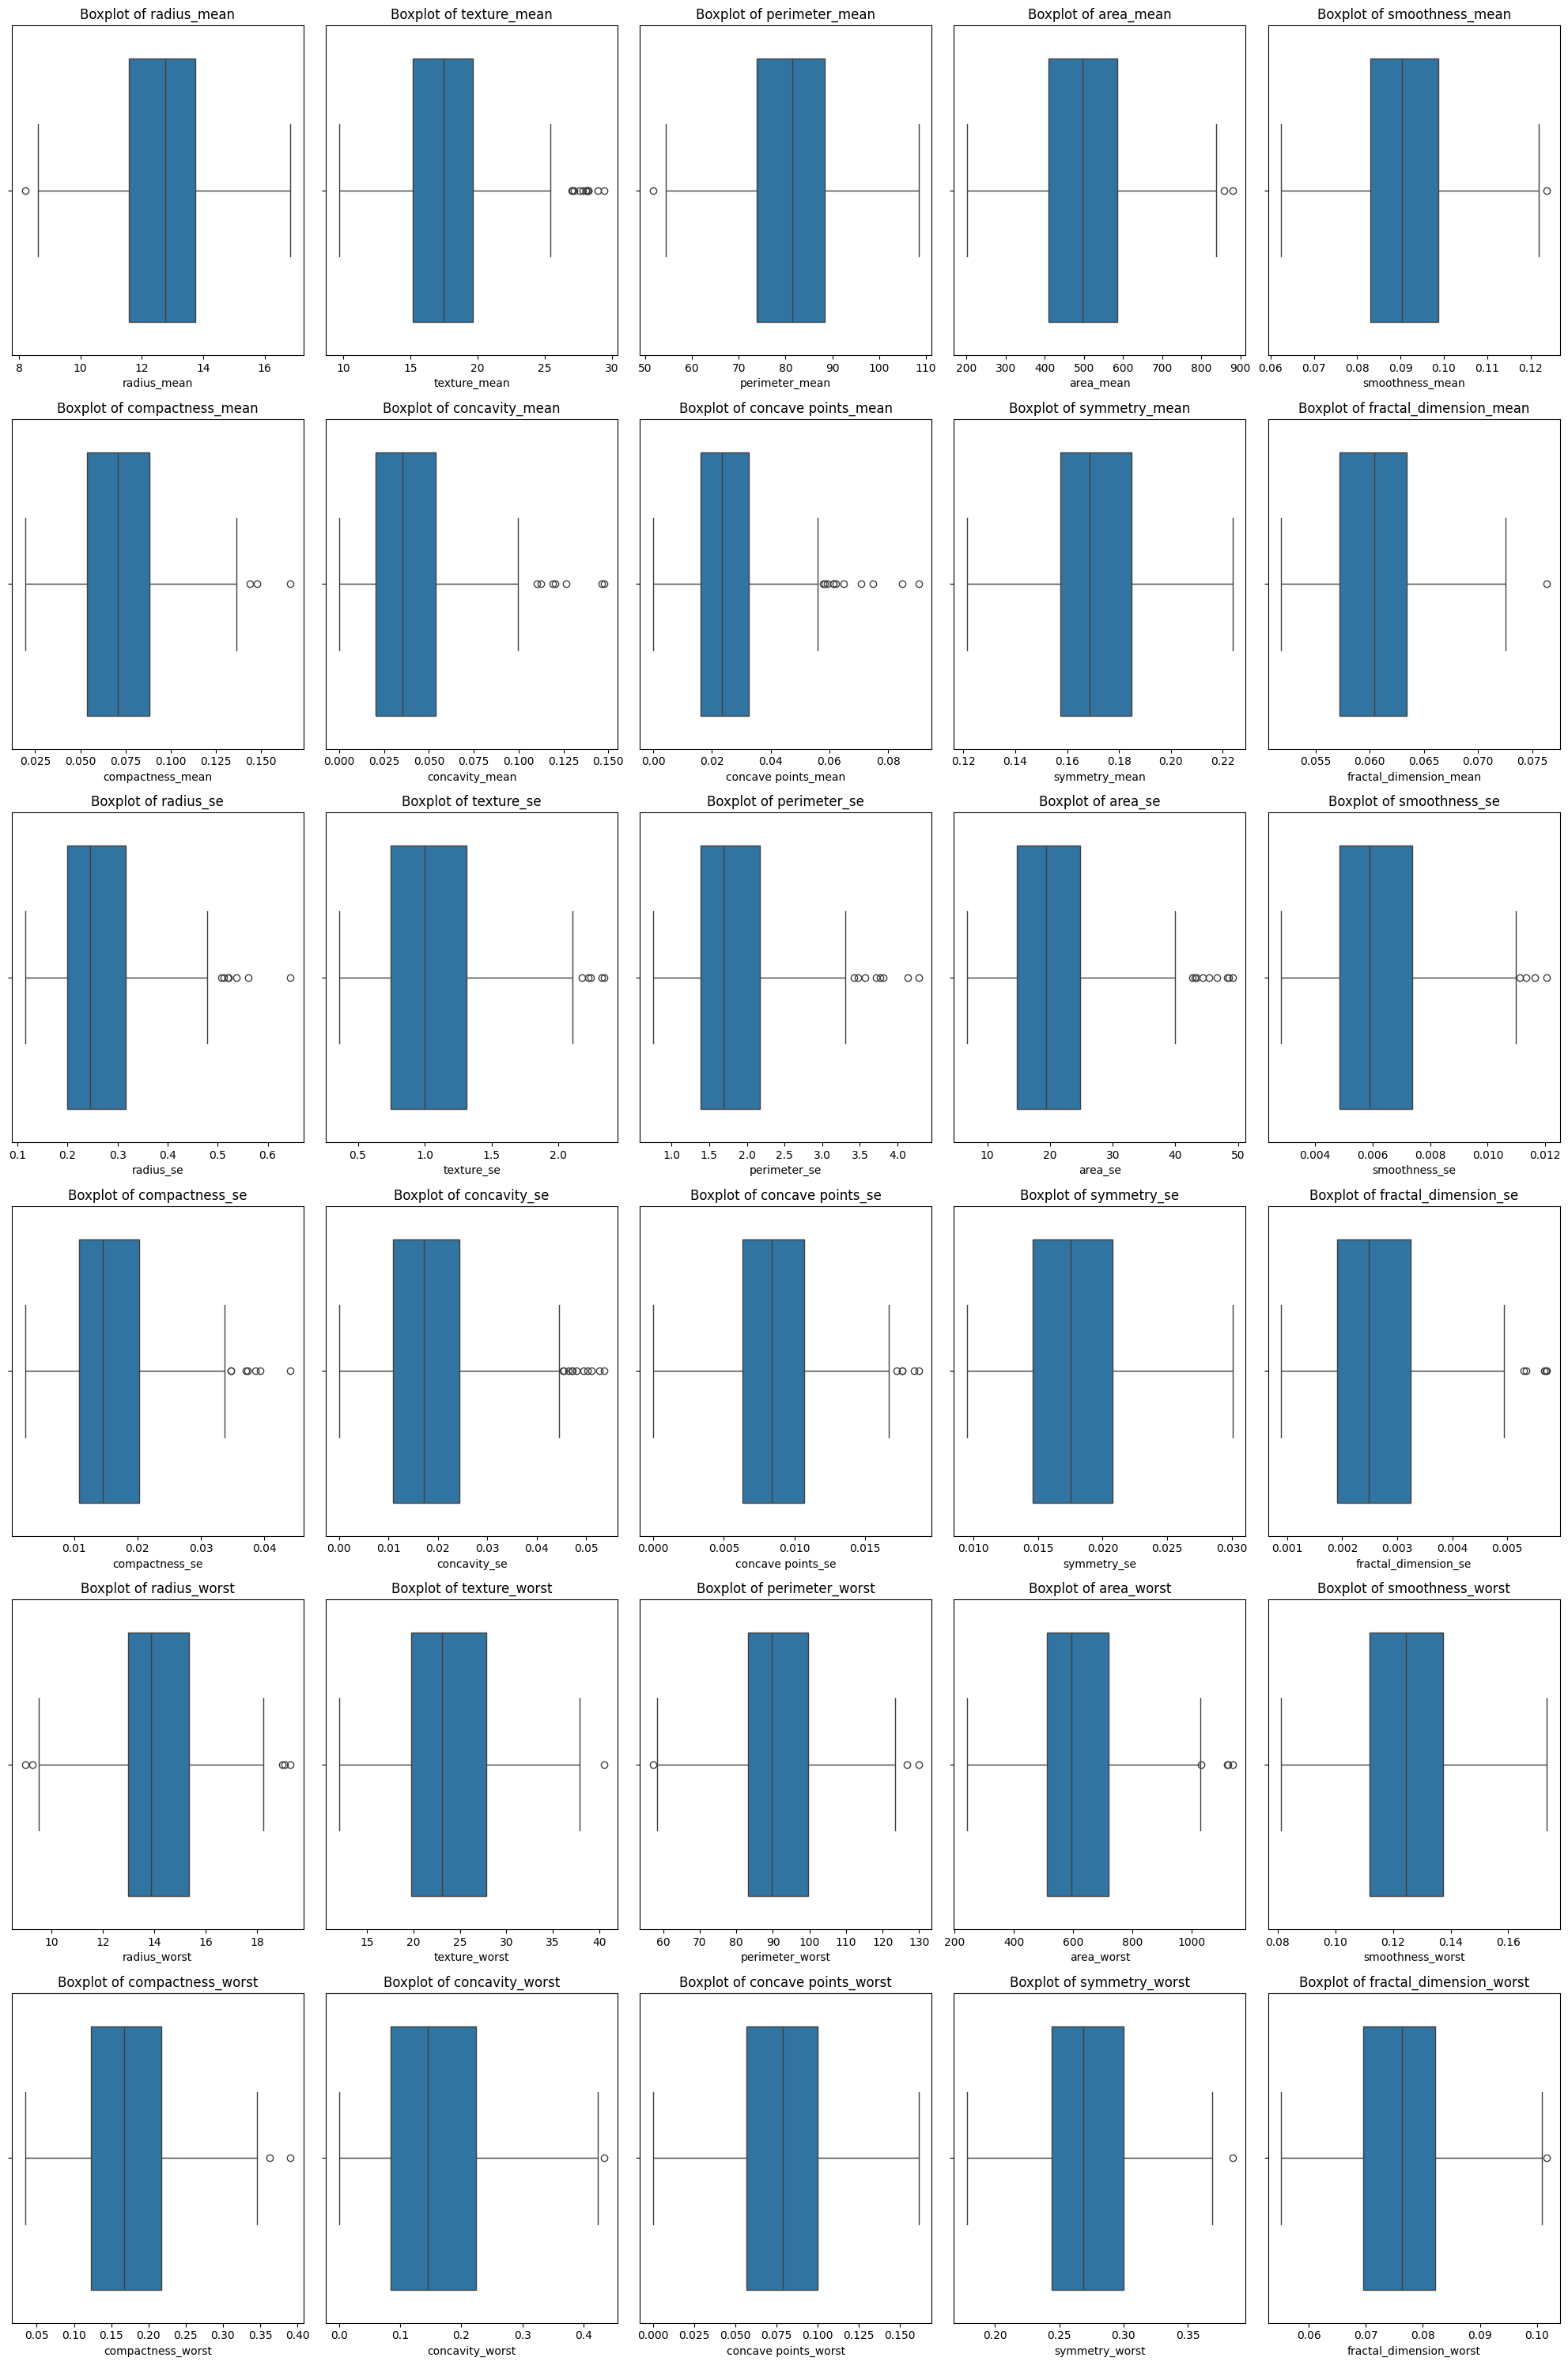

In [37]:


# Get all numerical columns from the DataFrame
all_numerical_cols = df.select_dtypes(include=np.number).columns

# Define columns you want to exclude
cols_to_exclude = ['id'] 
cols_to_exclude_lower = [col.lower() for col in cols_to_exclude]

# Create the final list of columns to plot
numerical_cols = [col for col in all_numerical_cols if col.lower() not in cols_to_exclude_lower]

n_cols_to_plot = len(numerical_cols)

if n_cols_to_plot == 0:
    print("No numerical columns found to plot (after exclusions).")
else:
    ncols = 5
    nrows = (n_cols_to_plot + ncols - 1) // ncols
    
    fig, axs = plt.subplots(nrows, ncols, figsize=(20, nrows * 5), squeeze=False)
    axs = axs.flatten()

    # --- UPDATED LOOP LOGIC ---
    plot_index = 0 # Use a separate index for placing plots on the axes
    for col in numerical_cols:
        
        # This check prevents the error:
        # Only plot if the column has at least one non-NaN value
        if df[col].notna().any():
            sns.boxplot(x=df[col], ax=axs[plot_index])
            axs[plot_index].set_title(f'Boxplot of {col}')
            plot_index += 1 # Only advance the plot index if we made a plot
        else:
            print(f"Skipping '{col}': Column contains only NaN values.")
    # --- END OF UPDATED LOGIC ---

    # Hide any unused subplots
    # Use 'plot_index' to know where the valid plots stopped
    for i in range(plot_index, len(axs)):
        axs[i].axis('off')

    plt.tight_layout()
    
    print(f"Successfully generated ")

after iqr 


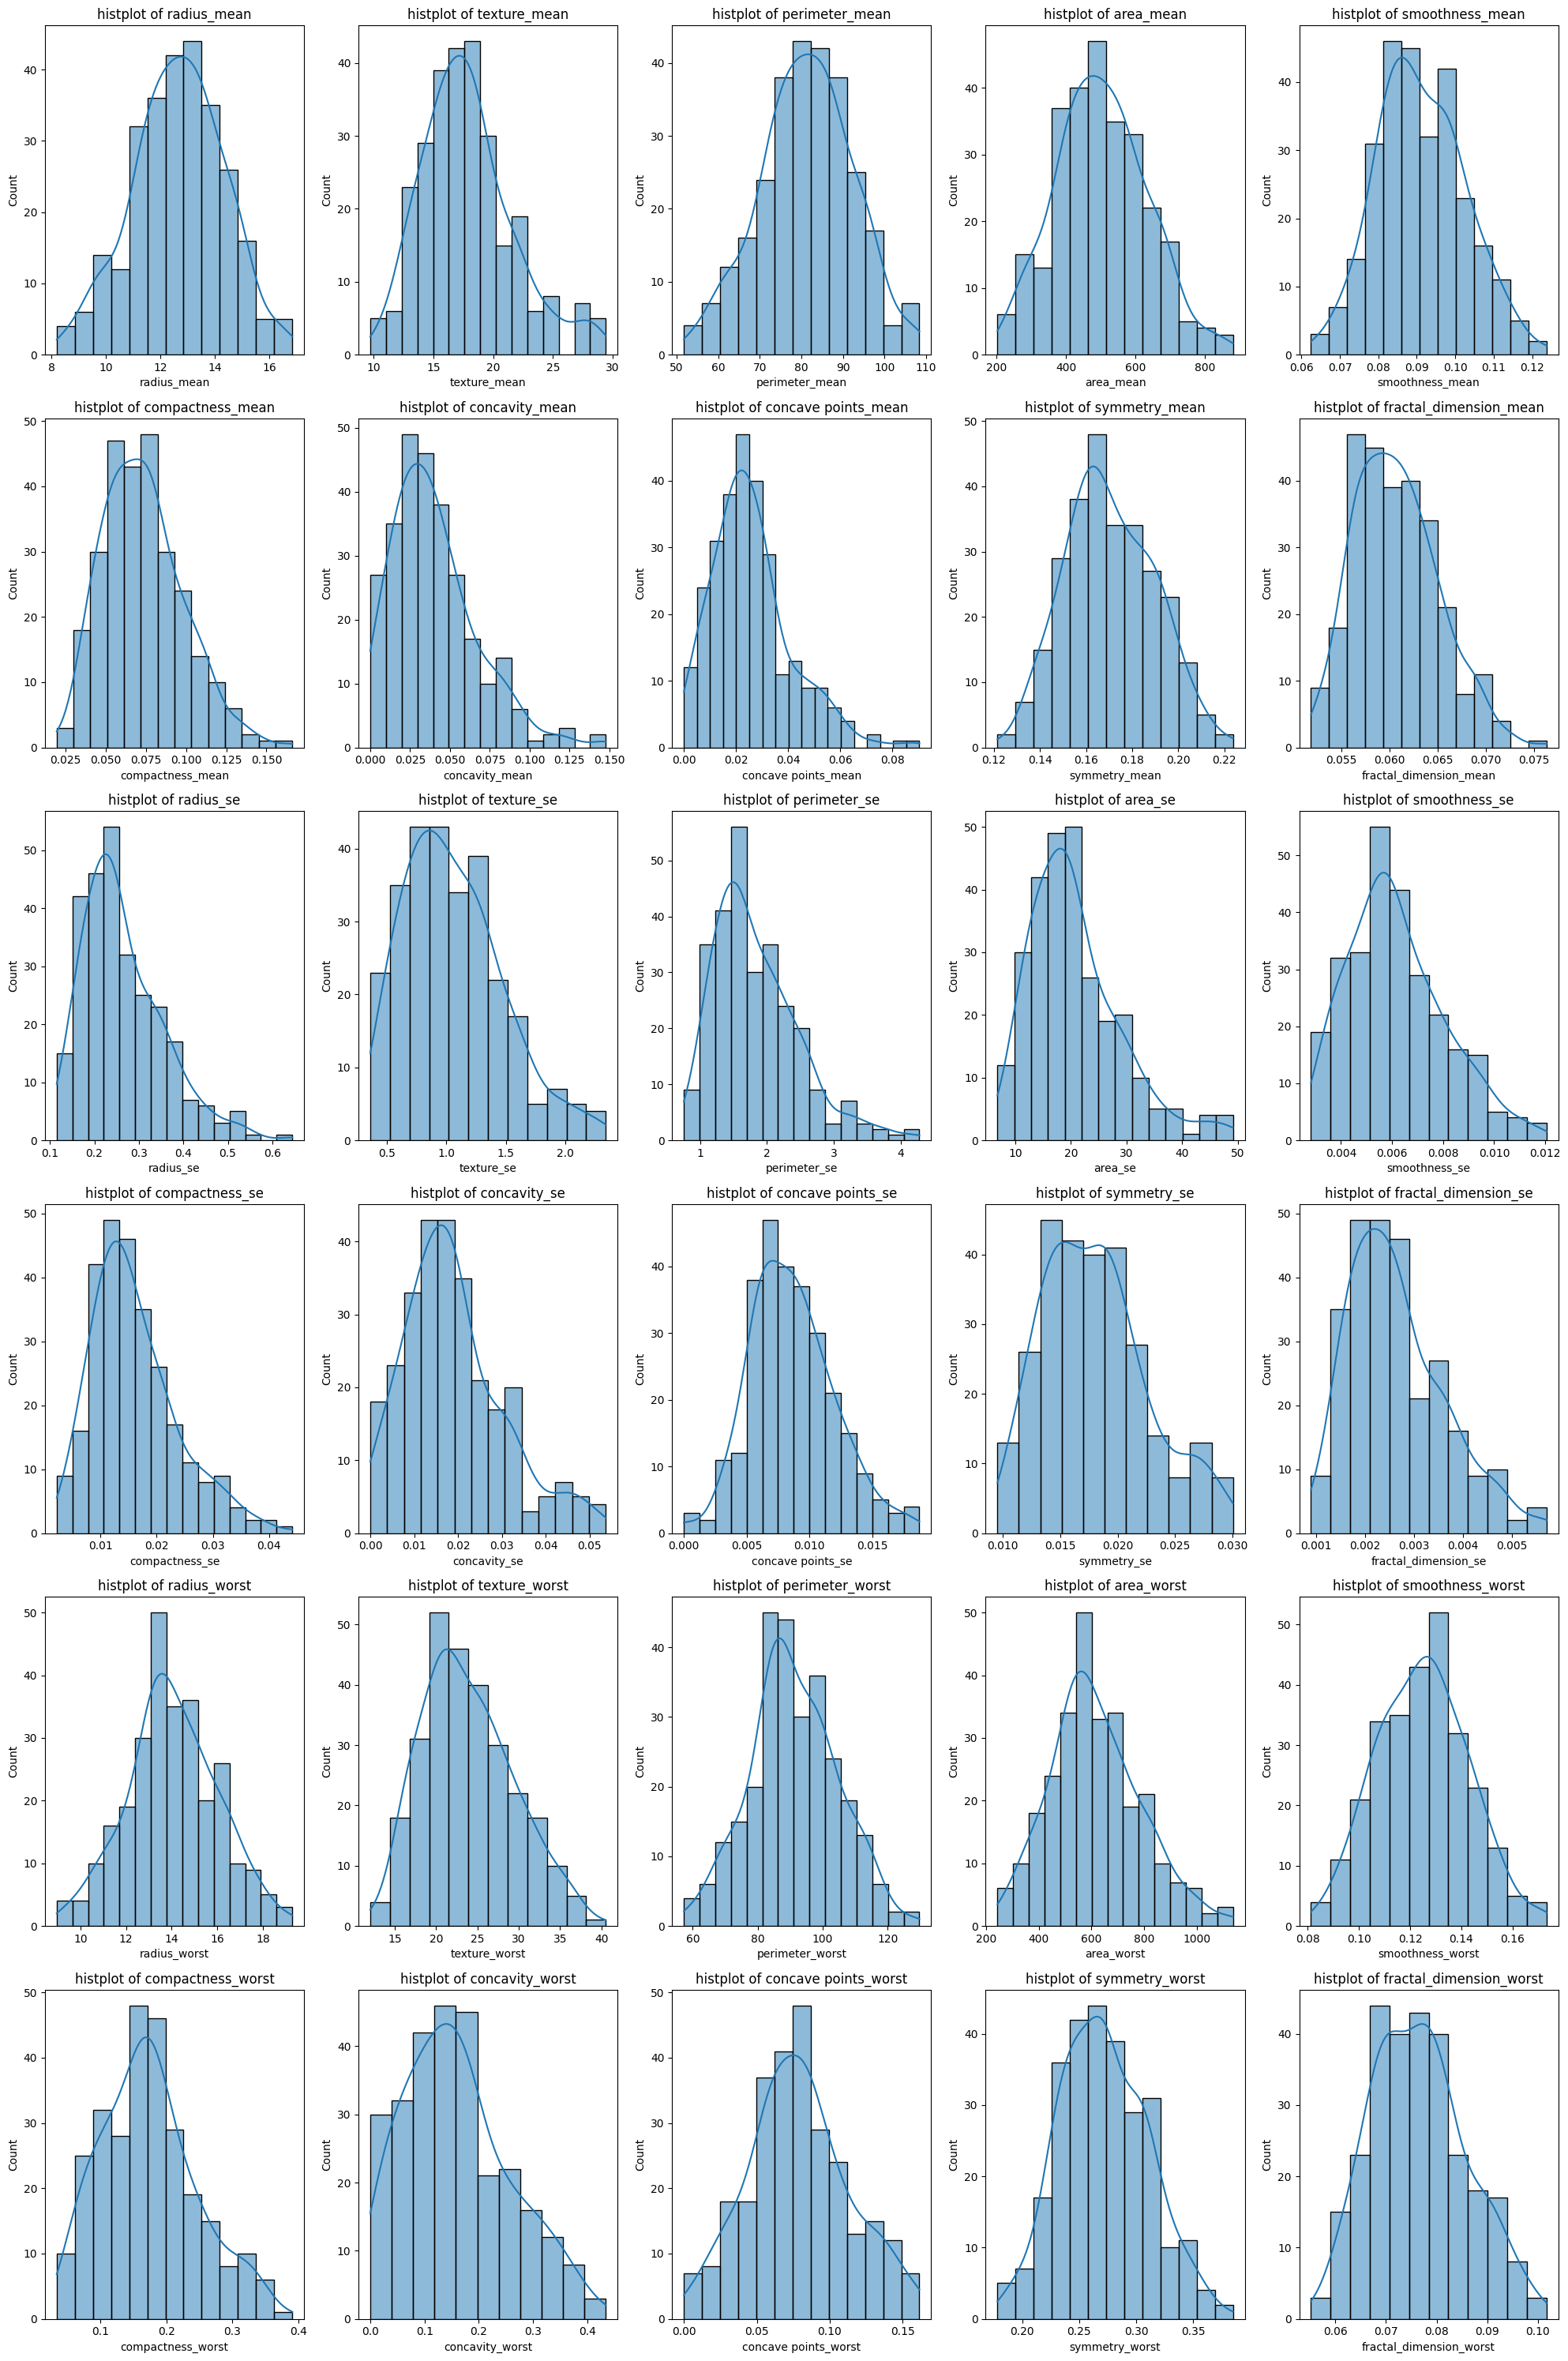

In [46]:


# Get all numerical columns from the DataFrame
all_numerical_cols = df.select_dtypes(include=np.number).columns

# Define columns you want to exclude
cols_to_exclude = ['id'] 
cols_to_exclude_lower = [col.lower() for col in cols_to_exclude]

# Create the final list of columns to plot
numerical_cols = [col for col in all_numerical_cols if col.lower() not in cols_to_exclude_lower]

n_cols_to_plot = len(numerical_cols)

if n_cols_to_plot == 0:
    print("No numerical columns found to plot (after exclusions).")
else:
    ncols = 5
    nrows = (n_cols_to_plot + ncols - 1) // ncols
    
    fig, axs = plt.subplots(nrows, ncols, figsize=(20, nrows * 5), squeeze=False)
    axs = axs.flatten()

    # --- UPDATED LOOP LOGIC ---
    plot_index = 0 # Use a separate index for placing plots on the axes
    for col in numerical_cols:
        
        # This check prevents the error:
        # Only plot if the column has at least one non-NaN value
        if df[col].notna().any():
            sns.histplot(x=df[col], ax=axs[plot_index],kde=True)
            axs[plot_index].set_title(f'histplot of {col}')
            plot_index += 1 # Only advance the plot index if we made a plot
        else:
            print(f"Skipping '{col}': Column contains only NaN values.")
    # --- END OF UPDATED LOGIC ---

    # Hide any unused subplots
    # Use 'plot_index' to know where the valid plots stopped
    for i in range(plot_index, len(axs)):
        axs[i].axis('off')

    plt.tight_layout()
    
    print(f"after iqr ")

In [ ]:


# Get all numerical columns from the DataFrame
all_numerical_cols = df.select_dtypes(include=np.number).columns

# Define columns you want to exclude
cols_to_exclude = ['id'] 
cols_to_exclude_lower = [col.lower() for col in cols_to_exclude]

# Create the final list of columns to plot
numerical_cols = [col for col in all_numerical_cols if col.lower() not in cols_to_exclude_lower]

n_cols_to_plot = len(numerical_cols)

if n_cols_to_plot == 0:
    print("No numerical columns found to plot (after exclusions).")
else:
    ncols = 5
    nrows = (n_cols_to_plot + ncols - 1) // ncols
    
    fig, axs = plt.subplots(nrows, ncols, figsize=(20, nrows * 5), squeeze=False)
    axs = axs.flatten()

    # --- UPDATED LOOP LOGIC ---
    plot_index = 0 # Use a separate index for placing plots on the axes
    for col in numerical_cols:
        
        # This check prevents the error:
        # Only plot if the column has at least one non-NaN value
        if df[col].notna().any():
            sns.histplot(x=df[col], ax=axs[plot_index],kde=True)
            axs[plot_index].set_title(f'histplot of {col}')
            plot_index += 1 # Only advance the plot index if we made a plot
        else:
            print(f"Skipping '{col}': Column contains only NaN values.")
    # --- END OF UPDATED LOGIC ---

    # Hide any unused subplots
    # Use 'plot_index' to know where the valid plots stopped
    for i in range(plot_index, len(axs)):
        axs[i].axis('off')

    plt.tight_layout()
    
    print(f"after iqr")